# Extraction-Isotopologue-Orbitrap
#### Inputs: 
    a series of .isox files and a sequence.csv file, for an automated sequence of ESI-Orbitrap-MS injections

#### Outputs: 
    .xlsx file compiling the results
    .csv file with compiled, filtered scan data for the whole sequence

    
## 1. Load and pre-treat scans
    a. Import .isox data and sequence file from pathdata  
    b. Scan filtering, calculation of isotopologue ratios
    c. Data quality control

## 2. Block verification and filtering
    a. Extract block average ratios  
    b. Check blank TIC
    c. Check sample and standard TIC and scan durations
    d. Check for outlying behaviour between blocks
    e. Check for outlying behaviour within blocks
    f. Filtering of blocks if necessary

## 3. Calculation of delta values
    Bracketing, averaging of repeat injections

## 4. Export final results to excel
    Sheets for:
        Block averages
        Bracketed internal delta values
        Averaged bracketed internal delta values

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime
current_datetime = datetime.now()
current_date_string = current_datetime.strftime("%Y-%m-%d")
pd.options.display.float_format = '{:.2f}'.format

In [51]:
### INPUTS: DATA SOURCE 
pathdata = 'put your path to the folder containing .isox files here'
seq_filename = 'sequence.csv' # must be in the same folder as .isox files

### INPUTS: DATA OUTPUT 
pathresults = 'results_'+current_date_string
output_file = 'results_'+current_date_string+'.xlsx'

# create folder for results in current path
def create_folder(directory, folder_name):
    # Combine the directory path and folder name
    folder_path = os.path.join(directory, folder_name)
    if not os.path.exists(folder_path):
        try:
            # Create the folder
            os.makedirs(folder_path)
            print(f"Folder '{folder_name}' created successfully at '{directory}'.")
        except OSError as e:
            print(f"Error creating folder: {e}")
    else:
        print(f"Folder '{folder_name}' already exists at '{directory}'.")

create_folder('',pathresults)

Folder 'results_2026-04-10' already exists at ''.


## 1. Load and pre-treat scans
#### a.  Import of .isox files and sequence.csv from pathdata

In [35]:
# Import sequence file

seq = pd.read_csv(os.path.join(pathdata,seq_filename),header=1)
seq = seq.loc[:,[col for col in seq.columns if col not in ['Process Method','Calibration File','Comment']]]

# fill in compound and experiment column based on method file name
seq['Expt']=''
seq['Compound']=''
for i in seq.index:
    if 'NO3' in seq.loc[i,'Instrument Method']:
        seq.loc[i,'Compound'] = 'NO3'
    elif 'SO4' in seq.loc[i,'Instrument Method']:
        seq.loc[i,'Compound'] = 'SO4'
    elif 'SO3' in seq.loc[i,'Instrument Method']:
        seq.loc[i,'Compound'] = 'SO3'
    if ('noM0' in seq.loc[i,'Instrument Method']) or ('nom0' in seq.loc[i,'Instrument Method']):
        seq.loc[i,'Expt']='noM0'
    elif 'Full_spectrum' in seq.loc[i,'Instrument Method']:
        seq.loc[i,'Expt']='Full spectrum'
        seq.loc[i,'Compound']=''
    else:
        seq.loc[i,'Expt']='M0'
        
# display summary
seq.groupby('Position').first().sort_values('Sample ID')

,Sample Type,File Name,Sample ID,Path,Instrument Method,Inj Vol,Sample Name,Expt,Compound
Position,,,,,,,,,
G:D1,Unknown,250110_001,1,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,USGS35-ISD,M0,NO3
G:C7,Unknown,250110_009,9,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,USGS34-2,M0,NO3
G:B8,Unknown,250110_011,11,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,C27,M0,NO3
G:B7,Unknown,250110_013,13,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,C26,M0,NO3
G:C6,Unknown,250110_015,15,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,C39,M0,NO3
G:C1,Unknown,250110_021,21,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,C29-31,M0,NO3
G:C8,Unknown,250110_023,23,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,USGS35-2,M0,NO3
G:B5,Unknown,250110_025,25,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,C22-23,M0,NO3
G:B3,Unknown,250110_029,29,C:\Xcalibur\data\Col du Dome\250110_CDD-22-39_...,C:\Xcalibur\methods\Vanquish_Neo\IFI_A50-50B\N...,25,USGS34-1,M0,NO3


#### b. Scan filtering
    
    i.  Filter using t_start and t_end (roughly select plateau)
    ii. Filter using TIC thresholds lower_threshold and upper_threshold relative to median TIC (remove large TIC instabilities and identify plateau)
    iii. Filter scans by TICxIT - removes scans beyond mean value ± 10 %
    iv. Remove data for isotoplogues detected in less than 99% of scans using isotopologue_threshold 
    v. If multiple peaks detected by isox for an isotopologue, select the most abundant

#### then calculation of ratio of isotopologue peaks to basepeak in every scan
Using 'ions.incremental' parameter (=estimated number of each ion in scan)

In [36]:
# data pretreatment
# load and filter .isox files from pathdata if their names appear in sequence file
# takes c. 0.5 sec per injection

print('Sequence file has',len(seq),'entries')

files = os.listdir(pathdata)

data_compiled = pd.DataFrame()

for i in seq.index:
    fn = seq.loc[i,'File Name']
    
    if fn+'.isox' in files:
        
        # load data
        data = pd.read_csv(os.path.join(pathdata,fn+'.isox'),delimiter='\t')
        
        # populate 'commpound', 'basepeak','position','sample ID','notes' columns in data
        if seq.loc[i,'Expt'] in ['M0','noM0']:
            
            data['compound']=seq.loc[i,'Compound']
            data['position']=seq.loc[i,'Position']
            data['sample_ID']=seq.loc[i,'Sample ID']
            data['sample_name']=seq.loc[i,'Sample Name']
            data['sample_type']=seq.loc[i,'Sample Type']
            if 'Notes' in seq.columns:
                data['notes']=seq.loc[i,'Notes']
            else:
                data['notes']=''
            if seq.loc[i,['Compound','Expt']].tolist()==['NO3','noM0']:
                data['basepeak']='15N'
            elif seq.loc[i,['Compound','Expt']].tolist()==['SO4','noM0']:
                data['basepeak']='34S'
            elif seq.loc[i,['Compound','Expt']].tolist()==['SO3','noM0']:
                data['basepeak']='34S'
            elif seq.loc[i,'Expt']=='M0':
                data['basepeak']='M0'
            data_to_filter = data.groupby('scan.no').first()

            # filter 1: time window
            t_start = 1
            t_end = 6
            data_to_filter = data_to_filter[(data_to_filter['time.min']>t_start)&(data_to_filter['time.min']<t_end)]

            # filter 2: TIC thresholds relative to median TIC - identifies 'plateau region' , removes extreme peaks in TIC
            lower_threshold = 0.8
            upper_threshold = 1.2
            median = data_to_filter['tic'].median()
            data_to_filter = data_to_filter[(data_to_filter['tic']>lower_threshold*median)&(data_to_filter['tic']<upper_threshold*median)]

            # filter 3: TICxIT window - discards the scans with extreme high/low TICxIT (Orbitrap ion population)
            percent = 10
            TICxIT = data_to_filter['tic'] * data_to_filter['it.ms']
            mean = TICxIT.mean()
            lower = mean * (1-0.01*percent)
            upper = mean * (1+0.01*percent)
            data_to_filter = data_to_filter[(TICxIT > lower) & (TICxIT < upper)]
            data = data[data['scan.no'].isin(data_to_filter.index)]

            # filter 4: select isotopologues that appear in most scans
            isotopologue_threshold=0.99
            n_scans = len(data[data['isotopolog']==data['basepeak']])
            def count_iso(data_single_iso):
                # remove isotopologues detected in <threshold scans
                if len(data_single_iso)>isotopologue_threshold*n_scans:
                    return data_single_iso
                else:
                    data_single_iso_too_low = data_single_iso.copy()
                    data_single_iso_too_low['scan.no']=np.nan
                    return data_single_iso_too_low
            data = data.groupby('isotopolog', group_keys=False).apply(count_iso).reset_index()
            # data.drop(columns = 'level_1', inplace=True)
            data.dropna(subset=['scan.no'],inplace=True) # clean df by removing rows where low abundance isotoplogues were identified

            # Filter 5: select only most abundant identified peak
            data = data.loc[data.groupby(['filename', 'compound', 'isotopolog','scan.no'])['ions.incremental'].idxmax()]

            # calculation of ratio of isotopologue peaks to basepeak
            def calc_ratio(scan):
                scan['ratio_to_basepeak'] = scan['ions.incremental'] / scan.loc[scan['isotopolog']==scan['basepeak'],'ions.incremental'].iloc[0]
                return scan
            data=data.groupby('scan.no', group_keys=False).apply(calc_ratio)
            data.reset_index(inplace=True)
            # data.drop(columns='level_1',inplace=True)
            data_compiled = pd.concat([data_compiled,data], ignore_index=True)

            print('Pretreated data file:',fn+'.isox', '(expt = '+seq.loc[i,'Expt']+',', len(data.groupby('scan.no').first()),'scans)')
            
        else:
            print('File',fn,"doesn't have M0 or noM0 method in sequence file. Ignoring this file")
    else:
        print('File',fn+'.isox not found at',pathdata)

# order columns usefully
first_cols =['sample_ID','filename','sample_type','sample_name','position','scan.no','time.min','basepeak','isotopolog','ions.incremental','ratio_to_basepeak','tic','it.ms','notes']
data_compiled= data_compiled[first_cols+[col for col in data_compiled.columns if col not in first_cols]]
data_compiled.groupby('sample_ID').first().reset_index()[first_cols]  

n_files = len(data_compiled['filename'].unique())
print('Loaded',n_files,'files out of',len(seq))

# display first scan for each sample
data_compiled.groupby('sample_ID').first().reset_index()[first_cols]

Sequence file has 194 entries
Pretreated data file: 250110_001.isox (expt = M0, 782 scans)
Pretreated data file: 250110_002.isox (expt = M0, 800 scans)
Pretreated data file: 250110_003.isox (expt = M0, 795 scans)
Pretreated data file: 250110_004.isox (expt = M0, 774 scans)
Pretreated data file: 250110_005.isox (expt = M0, 776 scans)
Pretreated data file: 250110_006.isox (expt = M0, 812 scans)
Pretreated data file: 250110_007.isox (expt = M0, 773 scans)
Pretreated data file: 250110_008.isox (expt = M0, 815 scans)
Pretreated data file: 250110_009.isox (expt = M0, 817 scans)
Pretreated data file: 250110_010.isox (expt = M0, 795 scans)
Pretreated data file: 250110_011.isox (expt = M0, 817 scans)
Pretreated data file: 250110_012.isox (expt = M0, 782 scans)
Pretreated data file: 250110_013.isox (expt = M0, 816 scans)
Pretreated data file: 250110_014.isox (expt = M0, 808 scans)
Pretreated data file: 250110_015.isox (expt = M0, 818 scans)
Pretreated data file: 250110_016.isox (expt = M0, 774 s

,sample_ID,filename,sample_type,sample_name,position,scan.no,time.min,basepeak,isotopolog,ions.incremental,ratio_to_basepeak,tic,it.ms,notes
0,1,250110_001,Unknown,USGS35-ISD,G:D1,129,1.00,M0,15N,1810.02,0.00,317795232.00,1.09,
1,2,250110_002,Unknown,USGS35-ISD,G:D1,129,1.00,M0,15N,1823.20,0.00,314962560.00,1.10,
2,3,250110_003,Unknown,USGS35-ISD,G:D1,129,1.00,M0,15N,1901.81,0.00,312204256.00,1.08,
3,4,250110_004,Unknown,USGS35-ISD,G:D1,129,1.00,M0,15N,1793.56,0.00,320189504.00,1.08,
4,5,250110_005,Unknown,USGS35-ISD,G:D1,129,1.00,M0,15N,1890.55,0.00,307399360.00,1.13,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,190,250110_190,Unknown,USGS35-ISD,G:D4,126,1.00,M0,15N,1908.85,0.00,218123184.00,1.59,
190,191,250110_191,Unknown,C25,G:B6,127,1.00,M0,15N,1900.02,0.00,88504104.00,3.86,
191,192,250110_192,Unknown,USGS35-ISD,G:D4,128,1.00,M0,15N,1787.10,0.00,213143920.00,1.63,
192,193,250110_193,Unknown,C38,G:C5,126,1.00,M0,15N,1797.60,0.00,106015000.00,3.24,


In [38]:
# saves this csv file, containing filtered scan data
data_compiled.to_csv(os.path.join(pathresults,'scandata_filtered.csv'))

#### c. Data quality control
    i. Check variability in Orbtitrap analyser temperature and mass migration.
Mass migration is okay, provided isox has still correcrtly identified the peaks (migration < isox tolerance)
Temperature swings can cause isotopologue ratio drift - investigate any large (<0.1C) and fast (<2h) swings

    ii. Check peak resolution range for weakest isotopologues  
If peak res range > 3000, 
check for a bimodal distribution (an artefact of different eFT processing of small and large peaks), 
if bimodal distribution, ignore this isotopologue

    iii. Check the time period extracted for outlying blocks
All samples and standards should have similar box plots, 
if not, might be changing ESI conditions or some contaminated samples - check stability was okay thoughout

Temperature range = 0.62 celcius
18O peak has m/z range 0.20 mmu


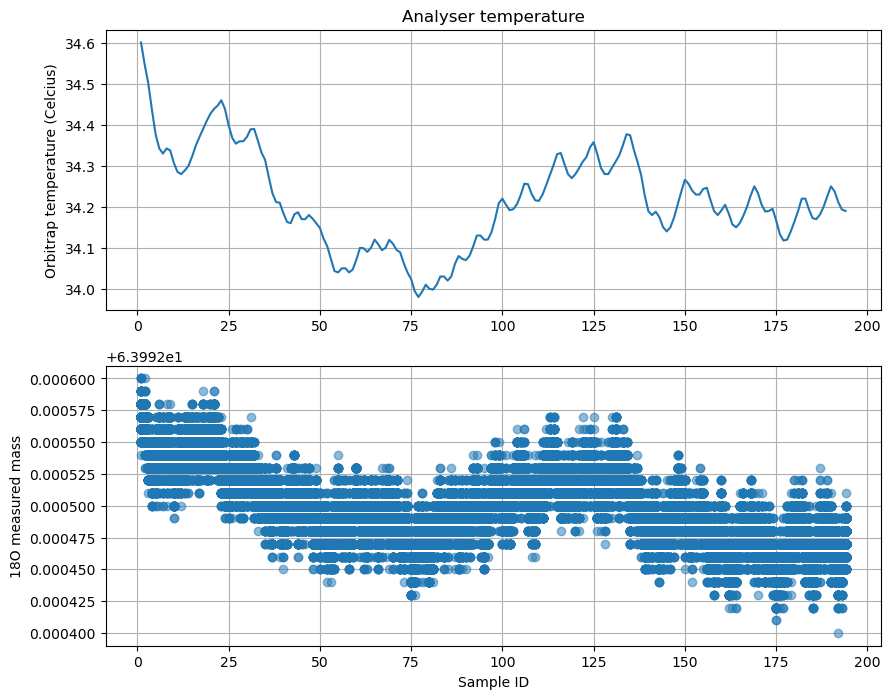

In [39]:
# Check 1:
# plot orbitrap temprature variations during run - variability affects mass accuracy and isotope ratios

fig,ax = plt.subplots(2, figsize=[10,8])
T = data_compiled.groupby('sample_ID')['analyzerTemperature'].mean()
ax[0].plot(T)
ax[0].set_ylabel('Orbitrap temperature (Celcius)')
ax[0].set_title('Analyser temperature')
ax[0].grid()

temp_range = T.max()-T.min()
print(f"Temperature range = {temp_range:.2f} celcius")

iso='18O'
data_i = data_compiled[data_compiled['isotopolog']==iso]
ax[1].plot(data_i['sample_ID'],data_i['mzMeasured'],lw=0,marker='o', alpha=0.5)
ax[1].grid()
ax[1].set_ylabel(iso+' measured mass')
ax[1].set_xlabel('Sample ID')
mz_range = data_i['mzMeasured'].max()-data_i['mzMeasured'].min()
print(f"{iso} peak has m/z range {mz_range*1e3:.2f} mmu")

In [40]:
# Check 2:
# verify that the range of peakResolution values < 3000 for all isotopologues

def func(data_single_iso,n,injs, inj_label):
    isotopolog_label = iso
    # Plot the histogram
    bin_width=250
    min_val = data_single_iso['peakResolution'].min()
    max_val = data_single_iso['peakResolution'].max()
    if max_val-min_val>3000:
        n+=1
        injs=injs+[inj_label]
        bins = np.arange(min_val, max_val + bin_width, bin_width)
        data_single_iso['peakResolution'].hist(bins=bins,alpha=0.5, label=isotopolog_label)  
    return n, injs
        
 # count instances of >3000
for iso in data_compiled['isotopolog'].unique():
    data_compiled_iso=data_compiled[data_compiled['isotopolog']==iso]
    injs=[]
    n=0
    for index, group in data_compiled_iso.groupby([ 'filename']):
        sample_name=group['sample_name'].iloc[0]
        n, injs = func(group, n,injs,index[0]+': '+sample_name)
    if n==0:
        print(iso ,'All isotopologue peak resolution ranges are < 3000')
    else:
        print(iso, n,'injections with peak resolution range >3000')
        print(injs)

        plt.title(iso+': Verification of peak resolution (check for bimodal distribution)')
        plt.xlabel('peakResolution')
        plt.ylabel('Frequency')
        plt.show()


/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76809/2614220968.py:22: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for index, group in data_compiled_iso.groupby([ 'filename']):
/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76809/2614220968.py:22: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for index, group in data_compiled_iso.groupby([ 'filename']):
/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76809/2614220968.py:22: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a sing

15N All isotopologue peak resolution ranges are < 3000
17O All isotopologue peak resolution ranges are < 3000
18O All isotopologue peak resolution ranges are < 3000
M0 All isotopologue peak resolution ranges are < 3000


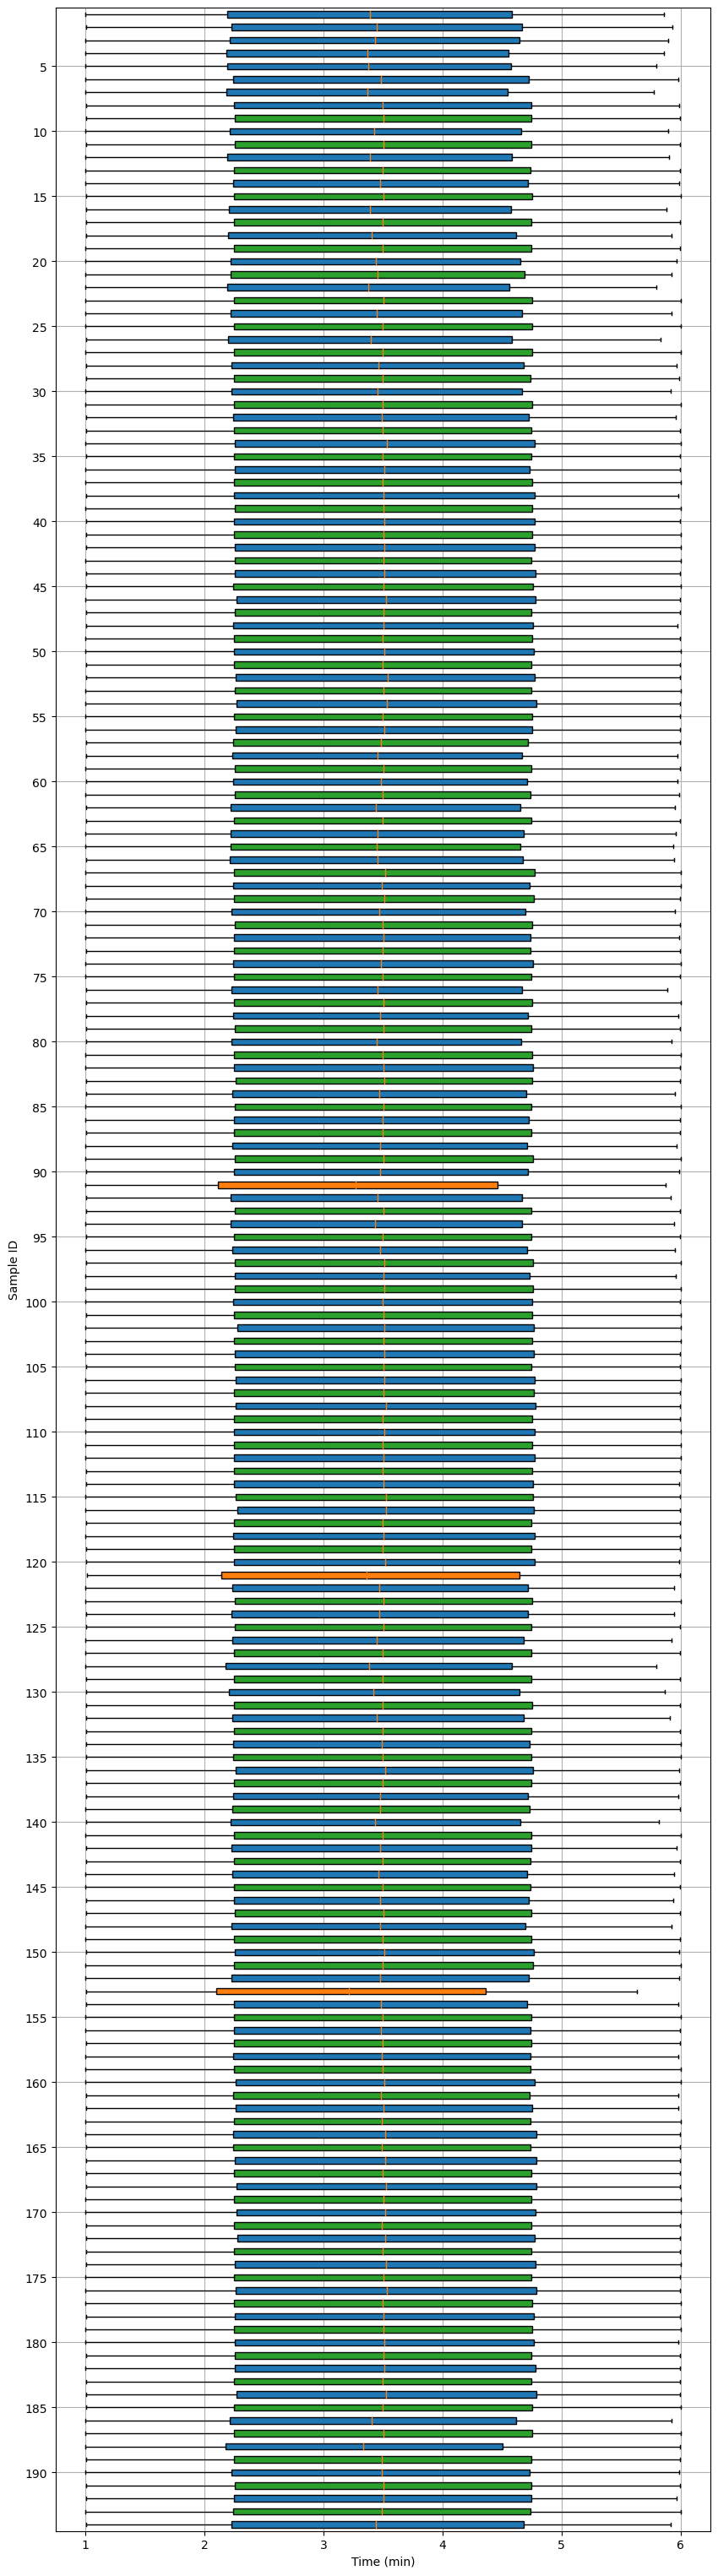

In [41]:
# Check 3:
# plot extracted time periods - check for outliers (nb: blank injections will often look different to samples)
# check the chromatograms for injections with outlying box plots - did something go wrong?

def extract_times(injection_data):
    t = injection_data[['time.min','sample_type']]
    return t

# colour box plots by sample type (spl/intref/blk)
# tuple for internal standard names
intrefs=('USGS35-IS','VS-IS')
# tuple for blank names
blanks=('MQ','MeOH')
data_compiled['sample_type']='Sample'
data_compiled.loc[data_compiled['sample_name'].str.startswith(intrefs), 'sample_type']='Internal reference'
data_compiled.loc[data_compiled['sample_name'].str.startswith(blanks), 'sample_type']='Blank'

# Group by 'sample_ID' and apply the function
t = data_compiled.groupby('sample_ID', group_keys=True).apply(extract_times)

t_list = [t_group['time.min'].values for name, t_group in t.groupby('sample_ID')]
type_list = [type for type in t.groupby('sample_ID').first()['sample_type']]
ID_list = [int(ID) for ID in t.index.levels[0]]

# colours
colorlist=type_list.copy()
for i,type in enumerate(type_list):
    if type == 'Internal reference':
        colorlist[i]='#1f77b4'
    if type == 'Sample':
        colorlist[i]='#2ca02c'
    if type == 'Blank':
        colorlist[i]='#ff7f0e'

fig,ax = plt.subplots(figsize=(10, 0.2*len(ID_list)))
boxplot = ax.boxplot(t_list, labels=ID_list, whis=[0,100],vert=False,patch_artist=True)

# colour box plots
for patch, color in zip(boxplot['boxes'], colorlist):
    patch.set_facecolor(color)

ax.set_ylabel('Sample ID')
ax.set_xlabel('Time (min)')
ax.grid()
ax.invert_yaxis()
ax.set_yticks([val for val in ax.get_yticks() if val%5==0])
ax.set_yticklabels([val for val in ax.get_yticks() if val%5==0]);

## 2. Injection averaging and filtering
#### a. Extract block averages from scan data

In [42]:
# uses groupby() to calculate averages, alongside a copy of all other metadata to a summary dataframe 'summ'

data = data_compiled.copy()
data['blockname']=data['filename'].copy()

# Extract blocknames
blocknames = data.groupby('sample_ID').first()['blockname']
isotopologues = [iso for iso in data[data['isotopolog']!=data['basepeak']]['isotopolog'].unique()]
# DataFrame for averaged ratios and metadata
summ = pd.DataFrame(columns=['sample_ID','filename','sample_type','sample_name','position','blockname','compound','basepeak']+['ratio_'+iso for iso in isotopologues]+['sem_'+iso for iso in isotopologues]+['start_t_min','stop_t_min','scans','TIC_av','TIC_rse','TICxIT_av','TICxIT_std','integration_t_ms','scan_dur_ms','analyser_temp','notes'],index=blocknames)

for block,data_b in data.groupby('blockname'):
    summ.loc[block,['sample_ID','filename','sample_type','sample_name','position','blockname','compound','basepeak','notes']] = data_b[['sample_ID','filename','sample_type','sample_name','position','blockname','compound','basepeak','notes']].iloc[0]
    bp = data_b.loc[:,'basepeak'].iloc[0]
    
    # populate columns in summ dataframe
    for iso,data_bi in data_b.groupby('isotopolog'):
        if iso == bp:
            summ.loc[block,'start_t_min'] = data_bi['time.min'].min()
            summ.loc[block,'stop_t_min'] = data_bi['time.min'].max()
            summ.loc[block,'scans'] = len(data_bi)
            summ.loc[block,'TIC_av']= data_bi['tic'].mean()
            TIC_RSE_10scan_rolling = data_bi['tic'].rolling(window=10).std()/data_bi['tic'].rolling(window=10).mean()
            summ.loc[block,'TIC_rse']=  TIC_RSE_10scan_rolling.mean()*np.sqrt(10)
            summ.loc[block,'TICxIT_av']=np.mean(data_bi['tic']*data_bi['it.ms'])
            summ.loc[block,'TICxIT_std']=np.std(data_bi['tic']*data_bi['it.ms'])
            summ.loc[block,'integration_t_ms']= data_bi['it.ms'].mean()
            summ.loc[block,'scan_dur_ms'] = data_bi['time.min'].diff().median()*60*1000
            summ.loc[block,'analyser_temp'] = data_bi['analyzerTemperature'].mean()
        if iso!=bp:
            summ.loc[block,'ratio_'+iso] = data_bi['ratio_to_basepeak'].mean()
            summ.loc[block,'sem_'+iso] = data_bi['ratio_to_basepeak'].sem()
            
summ = summ.sort_values('sample_ID')

print('Loaded '+ str(len(blocknames)) + ' sorted data blocks for samples:\n',summ[summ['sample_type']!='Internal standard']['sample_name'].unique())

summ.groupby('sample_name').first()

Loaded 194 sorted data blocks for samples:
 ['USGS35-ISD' 'USGS34-2' 'C27' 'C26' 'C39' 'C29-31' 'USGS35-2' 'C22-23'
 'USGS34-1' 'C32' 'C25' 'C28' 'C36' 'USGS35-1' 'C37' 'MQ-2' 'MQ-1' 'C38'
 'MQ-0']


,sample_ID,filename,sample_type,position,blockname,compound,basepeak,ratio_15N,ratio_17O,ratio_18O,...,stop_t_min,scans,TIC_av,TIC_rse,TICxIT_av,TICxIT_std,integration_t_ms,scan_dur_ms,analyser_temp,notes
sample_name,,,,,,,,,,,,,,,,,,,,,
C22-23,25,250110_025,Sample,G:B5,250110_025,NO3,M0,0.00,0.00,0.01,...,6.00,818,108996509.57,0.03,342777585.23,2998192.21,3.15,360.00,34.40,
C25,33,250110_033,Sample,G:B6,250110_033,NO3,M0,0.00,0.00,0.01,...,5.99,817,107599692.93,0.04,343019459.07,3322658.49,3.19,360.00,34.36,
C26,13,250110_013,Sample,G:B7,250110_013,NO3,M0,0.00,0.00,0.01,...,5.99,816,125126911.31,0.07,342810609.92,3715745.35,2.75,360.00,34.29,
C27,11,250110_011,Sample,G:B8,250110_011,NO3,M0,0.00,0.00,0.01,...,6.00,817,122177164.79,0.05,342875389.13,3270217.57,2.81,360.00,34.29,
C28,37,250110_037,Sample,G:B9,250110_037,NO3,M0,0.00,0.00,0.01,...,6.00,818,116410409.94,0.04,344092527.63,3237176.73,2.96,360.00,34.23,
C29-31,21,250110_021,Sample,G:C1,250110_021,NO3,M0,0.00,0.00,0.01,...,5.92,800,169672853.68,0.11,342495391.02,5409712.67,2.03,360.00,34.44,
C32,31,250110_031,Sample,G:C2,250110_031,NO3,M0,0.00,0.00,0.01,...,6.00,818,95957771.46,0.03,342699501.17,3189811.82,3.57,360.00,34.39,
C36,47,250110_047,Sample,G:C3,250110_047,NO3,M0,0.00,0.00,0.01,...,6.00,817,100484150.41,0.03,344021366.58,3108418.41,3.43,360.00,34.18,
C37,77,250110_077,Sample,G:C4,250110_077,NO3,M0,0.00,0.00,0.01,...,6.00,818,106500633.69,0.04,345412013.32,3204766.91,3.25,360.00,33.98,


#### b. Check blank TIC levels are acceptably low relative to samples/standards

In [43]:
# check blanks and samples TIC relative to internal reference TIC
# typical sample values ~ int ref
# typical blank values < 0.01 * int ref
intref=('USGS35-IS','VS-IS')
blanks=('MQ','MeOH')

TIC_intref = summ.loc[summ['sample_name'].str.startswith(intref),'TIC_av'].median()
TIC_blanks = summ.loc[summ['sample_name'].str.startswith(blanks),['sample_name','TIC_av']]
TIC_spl = summ.loc[(~ summ['sample_name'].str.startswith(intref)) & (~ summ['sample_name'].str.startswith(blanks)),'TIC_av'].median()
print('Median internal reference TIC ='+f" {TIC_intref:.2e}")
print('Median sample TIC ='+f" {TIC_spl:.2e} = {(TIC_spl/TIC_intref):.3f} * internal reference")
for row in TIC_blanks.index:
    print('Blank '+TIC_blanks.loc[row,'sample_name']+' TIC = '+f"{TIC_blanks.loc[row,'TIC_av']:.2e} = {(TIC_blanks.loc[row,'TIC_av']/TIC_intref):.3f} * internal reference")


Median internal reference TIC = 2.24e+08
Median sample TIC = 1.06e+08 = 0.472 * internal reference
Blank MQ-2 TIC = 5.22e+06 = 0.023 * internal reference
Blank MQ-1 TIC = 4.42e+06 = 0.020 * internal reference
Blank MQ-0 TIC = 3.62e+06 = 0.016 * internal reference


#### c. Plot TIC and time between scans
If TIC is low and scan frequency varies with TIC, less scans than the maximum are being made. Typically this is only the case for blank injections or no-M0 analyses
If scan frequency is lower than 0.1 Hz (for 1000 ms max IT and 10 microscans), AGC control is no longer active (max IT has been hit) and Orbitrap filling will depend on TIC (isotopologue data should be discarded)

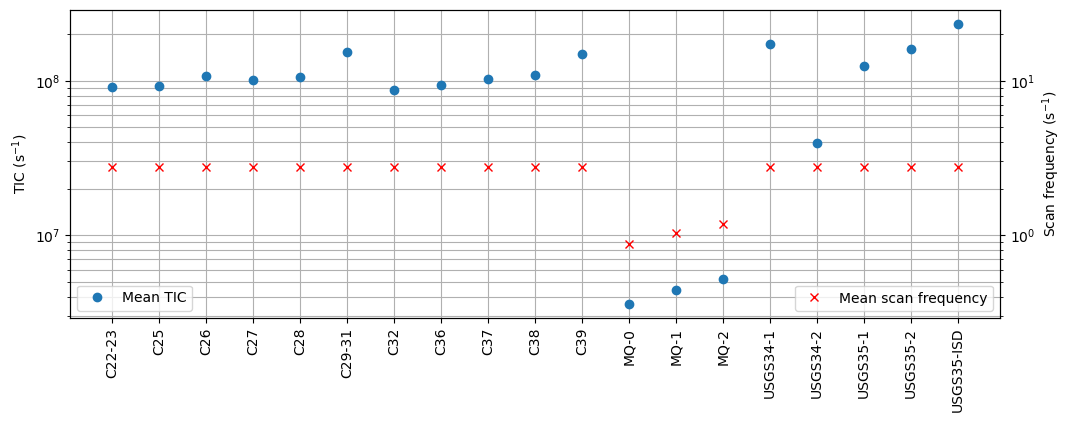

In [44]:
TICs = summ[['sample_name','TIC_av']].groupby('sample_name').mean()
scandurs = summ[['sample_name','scan_dur_ms']].groupby('sample_name').mean()/1000

fig,ax=plt.subplots(figsize=[12,4])
ax.plot(TICs, lw=0, marker = 'o',label='Mean TIC')
ax.set_yscale('log')
ax.set_ylabel('TIC (s$^{-1}$)')
plt.xticks(rotation=90);
ax.legend(loc='lower left')

ax2=ax.twinx()
ax2.plot(1/scandurs, lw=0, marker = 'x',c='r',ms=6,label='Mean scan frequency')
ax2.set_ylabel('Scan frequency (s$^{-1}$)')
plt.xticks(rotation=90)
ax2.set_yscale('log')
ax2.set_ylim([ax.get_ylim()[0]/1e7,ax.get_ylim()[1]/1e7])
ax2.legend(loc='lower right')

ax.grid(axis='both',which='both')

### d. Plot injection averages, check and filter outlying injections by TICxIT
Check for: 

        TIC or TIC RSE jumps
        Sample injections who differ from reference injection in TICxIT
        Strong or fast isotopologue ratio drift

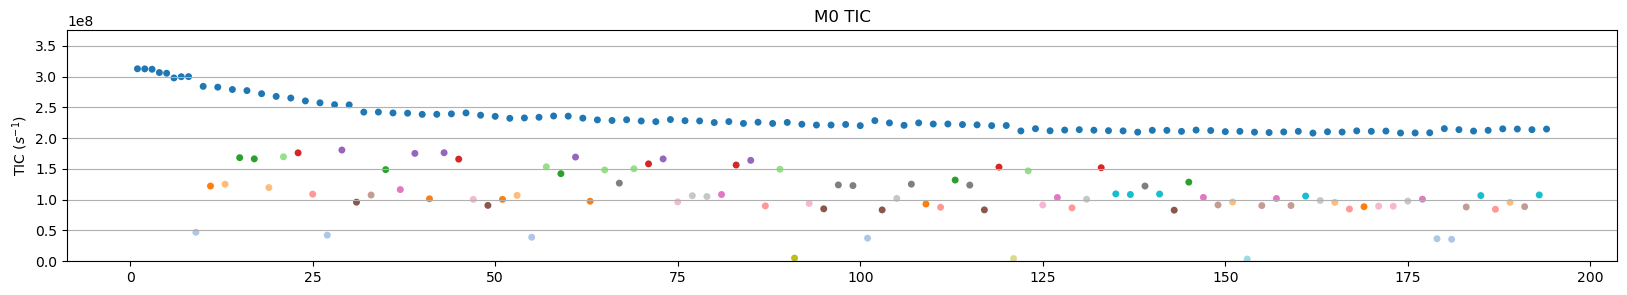

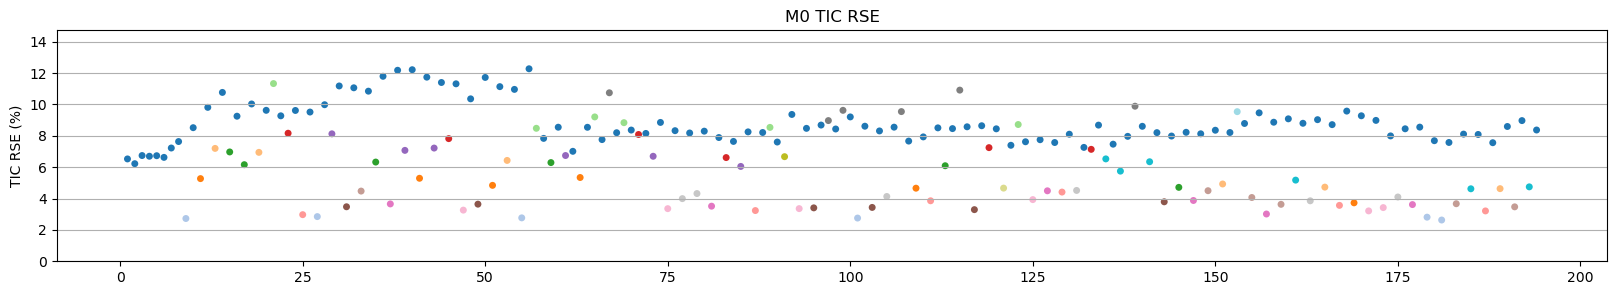

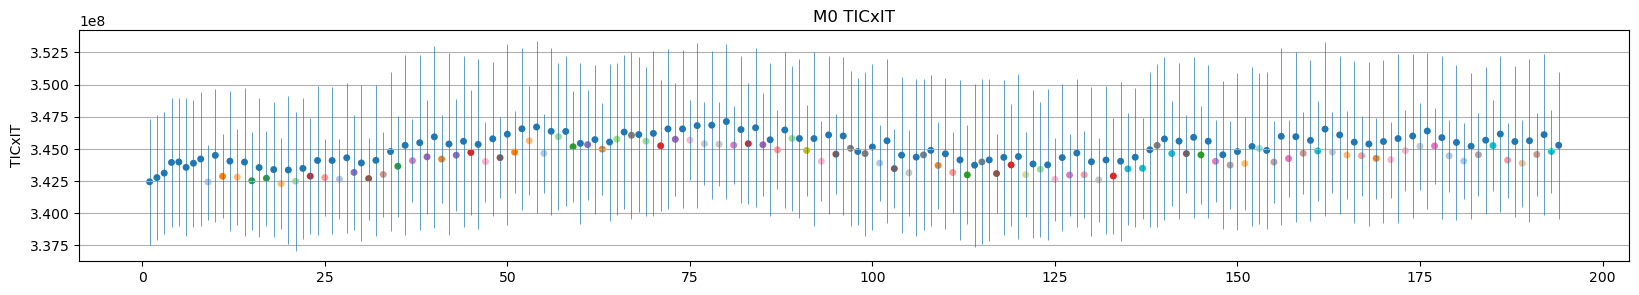

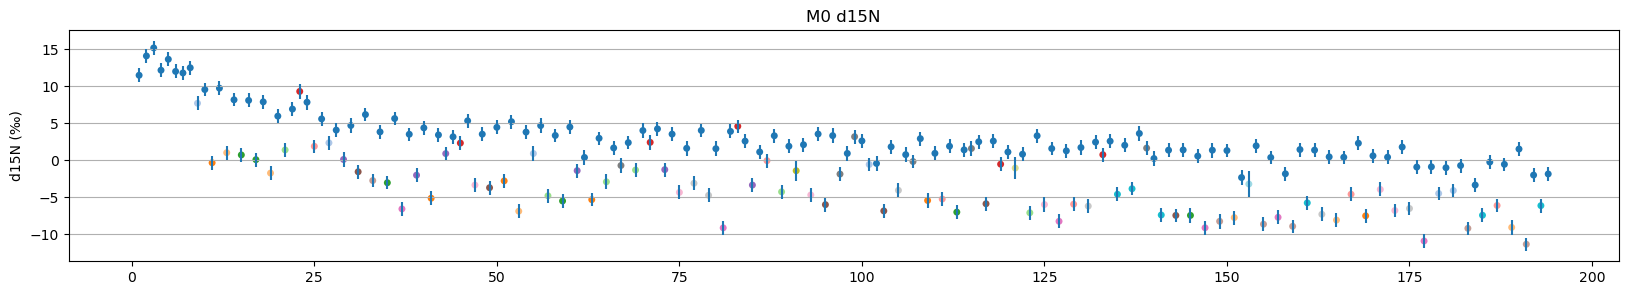

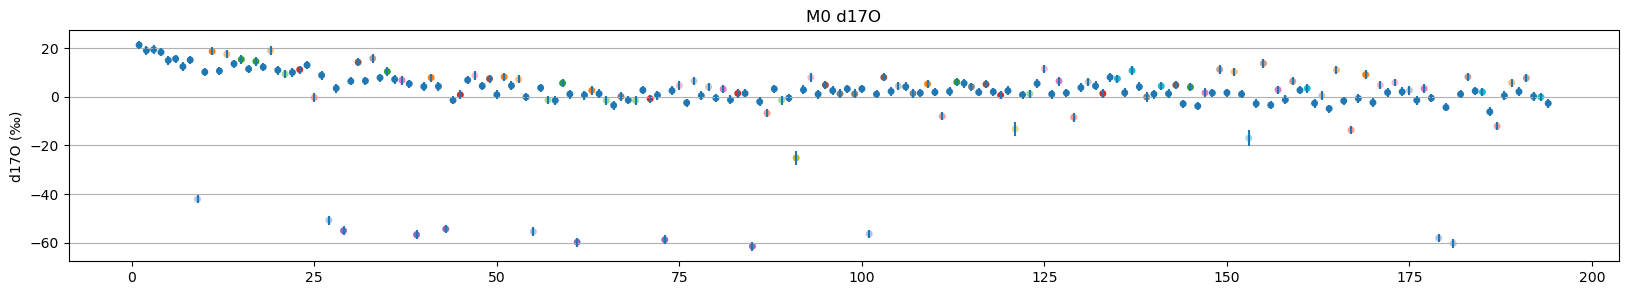

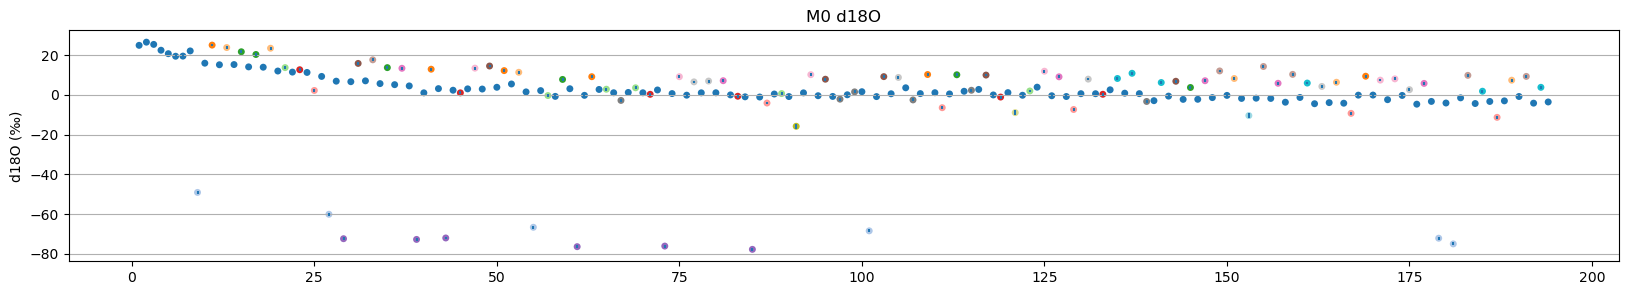

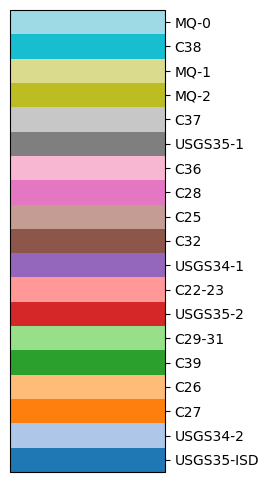

In [45]:
blocknames = summ.index
rcols = summ.columns[[col.startswith('ratio') for col in summ.columns]]

# identify M0 and/or noM0 experiments
exp_list = summ['basepeak'].unique()
for i,bp in enumerate(exp_list):
    if bp!='M0':
        exp_list[i]='noM0'

# separate M0 and noM0 data
for k,bp in enumerate(summ['basepeak'].unique()):
    summ1 = summ[summ['basepeak']==bp]
    if bp!='M0':
        exp='noM0'
    else:
        exp='M0'
    
    # colour mapping
    categories = summ['sample_name']
    from matplotlib.colors import ListedColormap
    tab10_cmap = plt.get_cmap('tab20')
    colors = tab10_cmap(np.linspace(0, 1, len(categories.unique())))
    discrete_cmap = ListedColormap(colors)
    category_mapping = {category: i for i, category in enumerate(categories.unique())}
    numeric_categories = np.array([category_mapping[category] for category in categories])
    discrete_cmap = plt.colormaps.get_cmap('tab20')

    
    # TIC plot
    fig,ax=plt.subplots(figsize=[20,3])
    scatter = ax.scatter(summ1['sample_ID'], summ1['TIC_av'], c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.',s=100)
    ax.grid(True, axis='y')
    ax.set_ylabel('TIC ($s^{-1}$)')
    ax.set_title(exp+' TIC')
    ax.set_ylim([0,1.2*max(summ1['TIC_av'])])
    
    # TIC RSE plot
    fig,ax=plt.subplots(figsize=[20,3])
    scatter = ax.scatter(summ1['sample_ID'], summ1['TIC_rse']*100, c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.',s=100)
    ax.grid(True, axis='y')
    ax.set_ylabel('TIC RSE (%)')
    ax.set_title(exp+' TIC RSE')
    ax.set_ylim([0,120*max(summ1['TIC_rse'])])
    
    # TICxIT plot
    fig,ax=plt.subplots(figsize=[20,3])
    scatter = ax.scatter(x=summ1['sample_ID'],  # x-values
                      y=summ1['TICxIT_av'],  # y-values
                      c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.',s=100)
    ax.errorbar(x=summ1['sample_ID'], y=summ1['TICxIT_av'], yerr=summ1['TICxIT_std'], lw=0.5,ls='none',fmt='none')
    ax.grid(True, axis='y')
    ax.set_ylabel('TICxIT')
    ax.set_title(exp+' TICxIT')

    # isotopologue ratio plots
    for i,col in enumerate(rcols):
        # check for empty column
        if len(summ1[col].dropna())>1:
            fig,ax=plt.subplots(figsize=[20,3])
            scatter = ax.scatter(summ1['sample_ID'], (summ1[col]/summ1[col].mean()-1)*1000, c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.', s=100)
            ax.errorbar(summ1['sample_ID'], (summ1[col]/summ1[col].mean()-1)*1000, yerr=(summ1['sem_'+col[6:]]/summ1[col])*1000, fmt='none')
            ax.grid(True, axis='y')
            ax.set_ylabel('d' + col.split('_')[-1] + ' (‰)')
            ax.set_title(exp+' d' + col.split('_')[-1])

     # large colour bar
    cfig,cbarax=plt.subplots(1,figsize=[2,6])
    cbar = plt.colorbar(scatter, ticks=np.unique(numeric_categories), boundaries=np.arange(len(np.unique(numeric_categories) )+ 1) - 0.5,cax=cbarax)
    cbar.set_ticklabels(categories.unique())


### e. Plot TIC and rolling mean isotopologue ratio for each block (optional)
Useful check if worried about memory effects or ESI instabilities affecting isotopologue ratios

In [46]:
if False:
    
    iso='18O'
    
    for (sample,basepeak), data_sb in data_compiled[data_compiled['isotopolog']==iso].groupby(['sample_name','basepeak']):

        fig,ax = plt.subplots(3, figsize = [10,5])
        ax[0].set_title(sample +', basepeak = '+basepeak)

        ref_18O = data_sb['ratio_to_basepeak'].mean()

        for sample_ID, data_sbi in data_sb.groupby('sample_ID'):

            scandur = data_sb['time.min'].diff().median()
            meandur = 0.5  # minutes for rolling mean calculation
            window_size = int(meandur / scandur)
            if basepeak=='M0':
                data_sbi['Rolling_18O'] = data_sbi['ratio_to_basepeak'].rolling(window=window_size, center=True).mean()
            else:
                data_sbi['Rolling_18O'] = data_sbi['ratio_to_basepeak'].rolling(window=int(window_size/2), center=True).mean()

            ax[0].plot(data_sbi['time.min']-data_sbi['time.min'].min(),data_sbi['tic'], label=sample_ID, lw=0.5,alpha=0.7)
            ax[0].grid(True,axis='both')
            ax[0].set_ylabel('TIC ($s^{-1}$)')
            ax[0].legend(ncols=4)        
            ax[0].set_xticklabels([])

            ax[1].plot(data_sbi['time.min']-data_sbi['time.min'].min(),data_sbi['tic']*data_sbi['it.ms'], label=sample_ID, lw=0.5,alpha=0.7)
            ax[1].grid(True,axis='both')
            ax[1].set_ylabel('TICxIT')   
            ax[1].set_xticklabels([])

            ax[2].plot(data_sbi['time.min']-data_sbi['time.min'].min(),1000*(data_sbi['Rolling_18O']/ref_18O-1), lw=0.5,alpha=0.7)
            ax[2].set_xlim(ax[0].get_xlim())
            ax[2].grid(True,axis='both')
            ax[2].set_ylabel('$\delta^{18}O$ (‰)')


            ax[-1].set_xlabel('Time (min)')

### f. Block filtering
Remove unfaithful injections using adjustable filters or by hand, if necessary

In [47]:
# filter blocks  using code below
summ['to_remove'] = False

# remove first injection of sequence
if True:    
    firstrow=summ[summ['sample_ID']==1]
    firstrow.loc[:,'to_remove']=True
    summ.loc[firstrow.index]=firstrow
    print('Removed first block: \n'+ str(np.array(firstrow[['sample_name','blockname']])))

# remove blank injections by sample_name
if True:
    blanks=('MQ','MeOH')
    blks = summ.loc[(~summ['to_remove'])&(summ['sample_name'].str.startswith((blanks)))]
    blks.loc[:,'to_remove']=True
    summ.loc[blks.index]=blks
    print('Removed '+str(len(blks)) + ' blank blocks: \n'+ str(np.array(blks[['sample_name','blockname']])))

# minimum TIC filter, to remove e.g. any injections from empty vials (adjust between M0 and no-M0 experiments)
if True:
    minTIC=1e7
    lowTICs = summ.loc[(~summ['to_remove'])&(summ['TIC_av']<minTIC)]
    lowTICs.loc[:,'to_remove']=True
    summ.loc[lowTICs.index]=lowTICs
    print('\nRemoved '+str(len(lowTICs)) + ' further blocks with low TIC \n'+ str(np.array(lowTICs[['sample_name','blockname']])))

# Outlying TICxIT filter (optional)
if False:
    thresholds = [0.98,1.02]
    print('\nTICxIT filtering with cutoff thresholds',thresholds,':')
    for i, index in enumerate(summ.index):
        if (i>0.5)&(i<len(summ)-1.5):
            ticxIT_av = summ.loc[:, 'TICxIT_av']
            current_inj = ticxIT_av.iloc[i]
            previous_inj = ticxIT_av.iloc[i - 1]
            next_inj = ticxIT_av.iloc[i + 1]
            ratio = current_inj / (0.5 * (previous_inj + next_inj))
            if (ratio<thresholds[0]) or (ratio>thresholds[1]):
                if not summ.loc[index,'sample_name'].endswith(('-ISD','-IS')):
                    if not summ.loc[index,'to_remove']:
                        summ.loc[index,'to_remove'] = True
                        print('Removed',summ.loc[index,'sample_name'],summ.loc[index,'blockname'])

    # Other injection numbers to remove by ID or name 
    ### SPECIFY INJECTIONS TO REMOVE HERE, IF NEEDED ###
    remove_ID = []
    remove_blockname = []
    remove_samplename = []
    extras = summ.loc[(~summ['to_remove'])&((summ['sample_ID'].isin(remove_ID))|(summ['blockname'].isin(remove_blockname))|(summ['sample_name'].isin(remove_samplename)))]
    extras.loc[:,'to_remove']=True
    summ.loc[extras.index]=extras
    print('\nRemoved '+str(len(extras)) + ' addional blocks manually: \n'+ str(np.array(extras['sample_name'])))

# remove labelled blocks
summ_filt = summ[summ['to_remove']==False].reset_index(drop=True)

# sort to seperate m0 and no-m0 data for bracketing
summ_filt = pd.concat([summ_filt[summ_filt['basepeak']=='M0'],summ_filt[summ_filt['basepeak']!='M0']]).reset_index(drop=True)
print('\nSeperated M0 and noM0 data:\n',
      summ_filt[['sample_name','blockname','basepeak']].head(5),
      '\n',summ_filt[['sample_name','blockname','basepeak']].tail(5))

# export summary files as csv  
summ[['blockname','to_remove']].to_csv(os.path.join(pathresults,'to_remove.csv'))
summ_filt.to_csv(os.path.join(pathresults,'summary_filtered.csv'))
summ.to_csv(os.path.join(pathresults,'summary_nonfiltered.csv'))
print('\nSaved unfiltered summary file as ' + os.path.join(pathresults,'summary_nonfiltered.csv.'))
print('Saved filtering list as ' + os.path.join(pathresults,'to_remove.csv.'))
print('Saved filtered summary file as ' + os.path.join(pathresults,'summary_filtered.csv.'))
print('\nRemoved blocks:')
summ[summ['to_remove']]

Removed first block: 
[['USGS35-ISD' '250110_001']]
Removed 3 blank blocks: 
[['MQ-2' '250110_091']
 ['MQ-1' '250110_121']
 ['MQ-0' '250110_153']]

Removed 0 further blocks with low TIC 
[]

Seperated M0 and noM0 data:
   sample_name   blockname basepeak
0  USGS35-ISD  250110_002       M0
1  USGS35-ISD  250110_003       M0
2  USGS35-ISD  250110_004       M0
3  USGS35-ISD  250110_005       M0
4  USGS35-ISD  250110_006       M0 
     sample_name   blockname basepeak
185  USGS35-ISD  250110_190       M0
186         C25  250110_191       M0
187  USGS35-ISD  250110_192       M0
188         C38  250110_193       M0
189  USGS35-ISD  250110_194       M0

Saved unfiltered summary file as results_2026-04-10/summary_nonfiltered.csv.
Saved filtering list as results_2026-04-10/to_remove.csv.
Saved filtered summary file as results_2026-04-10/summary_filtered.csv.

Removed blocks:


/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76809/510976941.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  firstrow.loc[:,'to_remove']=True
/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76809/510976941.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  blks.loc[:,'to_remove']=True


,sample_ID,filename,sample_type,sample_name,position,blockname,compound,basepeak,ratio_15N,ratio_17O,...,scans,TIC_av,TIC_rse,TICxIT_av,TICxIT_std,integration_t_ms,scan_dur_ms,analyser_temp,notes,to_remove
blockname,,,,,,,,,,,,,,,,,,,,,
250110_001,1,250110_001,Internal reference,USGS35-ISD,G:D1,250110_001,NO3,M0,0.00,0.00,...,782,312547190.73,0.07,342447329.56,4879859.62,1.10,360.00,34.60,,True
250110_091,91,250110_091,Blank,MQ-2,G:C9,250110_091,NO3,M0,0.00,0.00,...,344,5217870.67,0.07,344881655.54,3556086.71,66.49,840.00,34.08,,True
250110_121,121,250110_121,Blank,MQ-1,G:B2,250110_121,NO3,M0,0.00,0.00,...,315,4424417.77,0.05,342999533.85,3299873.66,78.14,960.00,34.29,,True
250110_153,153,250110_153,Blank,MQ-0,G:B1,250110_153,NO3,M0,0.00,0.00,...,245,3618579.93,0.10,345036215.09,5886699.81,95.72,1140.00,34.23,,True


Text(0.5, 1.0, 'M0 TIC')

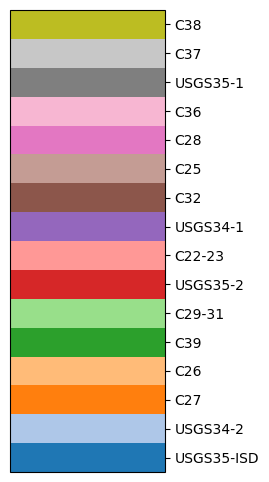

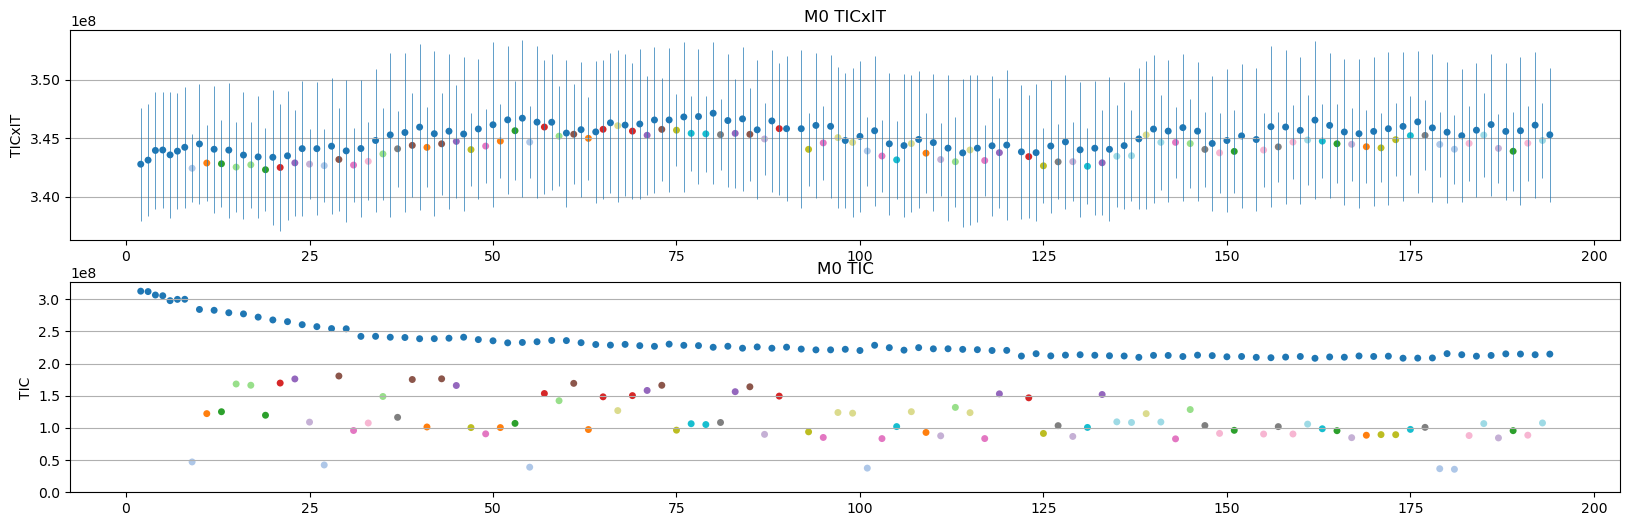

In [48]:
# plot after filtering
# colour mapping
categories = summ_filt['sample_name']
from matplotlib.colors import ListedColormap
tab10_cmap = plt.get_cmap('tab20')
colors = tab10_cmap(np.linspace(0, 1, len(categories.unique())))
discrete_cmap = ListedColormap(colors)
category_mapping = {category: i for i, category in enumerate(categories.unique())}
numeric_categories = np.array([category_mapping[category] for category in categories])
discrete_cmap = plt.colormaps.get_cmap('tab20')

# large cbar
cfig,cbarax=plt.subplots(1,figsize=[2,6])
cbar = plt.colorbar(scatter, ticks=np.unique(numeric_categories), boundaries=np.arange(len(np.unique(numeric_categories) )+ 1) - 0.5,cax=cbarax)
cbar.set_ticklabels(categories.unique())

# TICxIT plot
fig,ax=plt.subplots(2,figsize=[20,6])
scatter = ax[0].scatter(x=summ_filt['sample_ID'],  # x-values
                  y=summ_filt['TICxIT_av'],  # y-values
                  c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.',s=100)
ax[0].errorbar(x=summ_filt['sample_ID'], y=summ_filt['TICxIT_av'], yerr=summ_filt['TICxIT_std'], lw=0.5,ls='none',fmt='none')
ax[0].grid(True, axis='y')
ax[0].set_ylabel('TICxIT')
ax[0].set_title(exp+' TICxIT')

# TIC plot
scatter = ax[1].scatter(x=summ_filt['sample_ID'],  # x-values
                  y=summ_filt['TIC_av'],  # y-values
                  c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.',s=100)
ax[1].grid(True, axis='y')
ax[1].set_ylim([0,ax[1].get_ylim()[1]])
ax[1].set_ylabel('TIC')
ax[1].set_title(exp+' TIC')

## 3. Calculation of internal delta values
### a. Bracketing
Uses brackting formula $\delta = \frac{2R_i}{R_{i-1}+R_{i+1}}-1$ 
to calculate internal deltas for each isotopologue for every sample which is surrounded by internal standards.  
Saves internal deltas as 'internal_deltas_YYYY-MM-DD.csv'.  
Saves summary as 'internal_deltas_summary_YYYY-MM-DD.csv' with mean and sem for each isotopologue for each sample.

Plots bracketed internal delta values - check for major outliers


Automatically identified internal reference USGS35-ISD
Bracketed internal delta values relative to basepeak saved as results_2026-04-10/internal_deltas_2026-04-10.csv
Summarised ouptut saved as results_2026-04-10/internal_deltas_summary_2026-04-10.csv


/var/folders/rr/bz6rnlcn09b6b2ttxx8h8x5m0000gn/T/ipykernel_76809/3125212673.py:142: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  new_df.loc[:,col]=[int(new_df.loc[id,col]) for id in new_df.index]


,sample_type,position,basepeak,rel_to,scans_sample,scans_std,mean_d15N,mean_d17O,mean_d18O,err_d15N,err_d17O,err_d18O,TIC_sample,TIC_std,TIC_RSE_sample,TIC_RSE_std,TICxIT_sample,TICxIT_std,notes,order
sample_name,,,,,,,,,,,,,,,,,,,,
C22-23,Sample,G:B5,M0,USGS35-ISD M0 peak,4904,4627,-5.46,-10.23,-6.93,0.73,0.87,0.65,9.0e+07,2.2e+08,3.5%,8.4%,3.4e+08,3.5e+08,,0
C25,Sample,G:B6,M0,USGS35-ISD M0 peak,4900,4689,-9.01,8.94,12.93,0.59,1.70,0.68,9.3e+07,2.2e+08,4.0%,8.8%,3.4e+08,3.5e+08,,1
C26,Sample,G:B7,M0,USGS35-ISD M0 peak,4887,4687,-8.85,7.56,9.29,0.59,1.51,0.42,1.1e+08,2.4e+08,5.8%,9.3%,3.4e+08,3.5e+08,,2
C27,Sample,G:B8,M0,USGS35-ISD M0 peak,4901,4690,-8.29,5.53,9.07,0.47,1.36,0.49,1.0e+08,2.4e+08,4.9%,9.4%,3.4e+08,3.5e+08,,3
C28,Sample,G:B9,M0,USGS35-ISD M0 peak,4906,4645,-9.94,3.68,8.69,0.68,0.88,0.47,1.1e+08,2.2e+08,3.7%,9.0%,3.4e+08,3.5e+08,,4
C29-31,Sample,G:C1,M0,USGS35-ISD M0 peak,4805,4670,-6.58,-1.80,0.88,0.82,0.88,0.51,1.5e+08,2.3e+08,9.2%,9.0%,3.4e+08,3.5e+08,,5
C32,Sample,G:C2,M0,USGS35-ISD M0 peak,4903,4684,-8.13,5.12,9.12,0.47,0.86,0.42,8.7e+07,2.3e+08,3.5%,9.2%,3.4e+08,3.5e+08,,6
C36,Sample,G:C3,M0,USGS35-ISD M0 peak,4900,4660,-7.14,5.15,9.58,0.58,0.87,0.35,9.4e+07,2.2e+08,3.4%,9.2%,3.4e+08,3.5e+08,,7
C37,Sample,G:C4,M0,USGS35-ISD M0 peak,4901,4649,-7.03,3.57,6.60,0.49,0.93,0.48,1.0e+08,2.2e+08,4.2%,8.3%,3.4e+08,3.5e+08,,8


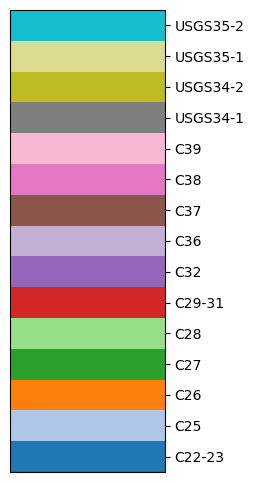

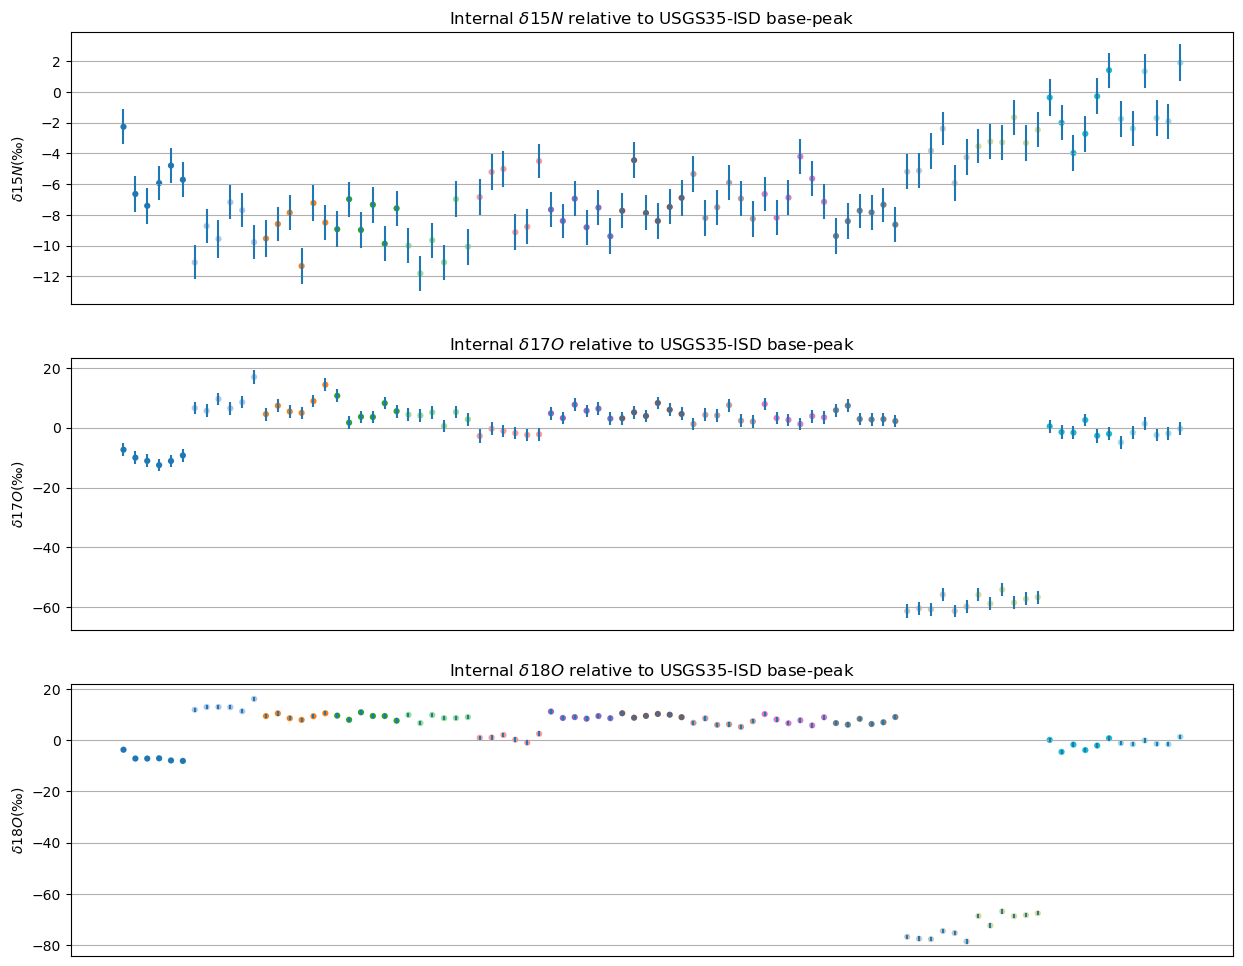

In [49]:
# identify internal reference
intrefs=('USGS35-IS','VS-IS')

ref_injs = summ_filt[summ_filt['sample_name'].str.startswith(intrefs)]
if len(ref_injs['sample_name'].unique())==1:
    # automatic identification of internal reference
    int_std = ref_injs['sample_name'].iloc[0]
    print('Automatically identified internal reference',int_std)
else:
    # manually input the name of internal refernce here
    int_std = 'USGS35-ISD'
    print("Internal reference manually selected:",int_std)
    
# identify isotopologs
isotopologues = [col.split('_')[1] for col in summ_filt.columns if col.split('_')[0]=='ratio']
    
# identify sample injections
samples = summ_filt[summ_filt['sample_name'] != int_std]
samples_delta = pd.DataFrame(columns=['sample_type','sample_name','position','blockname','basepeak']+['d'+iso for iso in isotopologues]+['err_d'+iso for iso in isotopologues]+['rel_to','TIC_sample','scans_sample','scans_std','analyser_temp_std_before','analyser_temp_std_after','analyser_temp_spl','notes'],index = samples.index)
samples_delta.loc[:,['sample_ID','sample_type','sample_name','position','blockname','basepeak','notes']]=samples.loc[:,['sample_ID','sample_type','sample_name','position','blockname','basepeak','notes']]


# bracketing
for i in samples.index:
    if i-1 in summ_filt.index and i+1 in summ_filt.index:
        if summ_filt.loc[i-1,'sample_name']== int_std and summ_filt.loc[i+1,'sample_name']==int_std:
            # calc delta
            R_i = summ_filt.loc[i,['ratio_'+iso for iso in isotopologues]]
            R_minus = summ_filt.loc[i-1,['ratio_'+iso for iso in isotopologues]]
            R_plus = summ_filt.loc[i+1,['ratio_'+iso for iso in isotopologues]]
            deltas = 2*R_i/(R_minus+R_plus)-1
            samples_delta.loc[i,['d'+iso for iso in isotopologues]] = deltas.tolist()
            # calc error
            e_i = summ_filt.loc[i,['sem_'+iso for iso in isotopologues]]
            e_minus = summ_filt.loc[i-1,['sem_'+iso for iso in isotopologues]]
            e_plus = summ_filt.loc[i+1,['sem_'+iso for iso in isotopologues]]
            err_d = e_i.copy()
            for sem_iso in e_i.index:
                err_d.loc[sem_iso] = ((2*e_i[sem_iso])**2 + e_minus[sem_iso]**2 + e_plus[sem_iso]**2)**0.5/(0.5*R_minus['ratio_'+sem_iso[4:]]+0.5*R_plus['ratio_'+sem_iso[4:]]+R_i['ratio_'+sem_iso[4:]])
            samples_delta.loc[i,['err_d'+iso for iso in isotopologues]] = err_d.tolist()
            
        samples_delta.loc[i,'rel_to'] = int_std+' '+samples_delta.loc[i,'basepeak']+' peak'
        samples_delta.loc[i,'TIC_sample']=summ_filt.loc[i,'TIC_av']
        samples_delta.loc[i,'TIC_std']=0.5*(summ_filt.loc[i-1,'TIC_av']+summ_filt.loc[i+1,'TIC_av'])
        samples_delta.loc[i,'TIC_RSE_sample']=summ_filt.loc[i,'TIC_rse'] 
        samples_delta.loc[i,'TIC_RSE_std']=summ_filt.loc[i-1,'TIC_rse']
        samples_delta.loc[i,'TICxIT_sample']=summ_filt.loc[i,'TICxIT_av']
        samples_delta.loc[i,'TICxIT_std']=0.5*(summ_filt.loc[i-1,'TICxIT_av']+summ_filt.loc[i+1,'TICxIT_av']) 
        samples_delta.loc[i,'scans_sample']=summ_filt.loc[i,'scans']
        samples_delta.loc[i,'scans_std']=0.5*(summ_filt.loc[i-1,'scans']+summ_filt.loc[i+1,'scans'])
        samples_delta.loc[i,'analyser_temp_std_before']=summ_filt.loc[i-1,'analyser_temp']
        samples_delta.loc[i,'analyser_temp_std_after']=summ_filt.loc[i+1,'analyser_temp']
        samples_delta.loc[i,'analyser_temp_spl']=summ_filt.loc[i,'analyser_temp']
        samples_delta.loc[i,'notes']=summ_filt.loc[i,'notes']
samples_delta.dropna(how='all',subset=['d'+iso for iso in isotopologues],inplace=True)
samples_delta = samples_delta.sort_values('sample_name').reset_index(drop=True)
samples_delta.reset_index(inplace=True,drop=True)

# save
samples_delta.to_csv(os.path.join(pathresults,'internal_deltas_'+current_date_string+'.csv'))
print('Bracketed internal delta values relative to basepeak saved as '+ os.path.join(pathresults,'internal_deltas_'+current_date_string+'.csv'))

# summarise internal deltas per sample/experiment combo
stats=pd.DataFrame()
stats['sample_ID']=samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['sample_ID']
stats['sample_name']=samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['sample_name']
stats['sample_type']=samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['sample_type']
stats['position']=samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['position']
stats['basepeak']=samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['basepeak']
stats['rel_to']=samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['rel_to']
stats['scans_sample']=samples_delta.groupby(['sample_name','basepeak'])['scans_sample'].sum().reset_index()['scans_sample']
stats['scans_std']=samples_delta.groupby(['sample_name','basepeak'])['scans_std'].sum().reset_index()['scans_std']
# mean delta
stats[['mean_d'+iso for iso in isotopologues]]=samples_delta.groupby(['sample_name','basepeak'])[['d'+iso for iso in isotopologues]].mean().reset_index()[['d'+iso for iso in isotopologues]]
# sem of N injections
sem=samples_delta.groupby(['sample_name','basepeak'])[['d'+iso for iso in isotopologues]].sem().reset_index()[['d'+iso for iso in isotopologues]]
# propogated error = sqrt(sum(err^2)/N))
def add_in_quadrature(errors):
    N = len(errors)
    return (np.sum(errors**2,axis=0)**0.5/N)
errprop = samples_delta.groupby(['sample_name','basepeak'])[['err_d'+iso for iso in isotopologues]].apply(add_in_quadrature).reset_index()[['err_d'+iso for iso in isotopologues]]
# select the grater error val
sem.columns = errprop.columns
stats[['err_d'+iso for iso in isotopologues]] = np.fmax(errprop,sem)

stats['TIC_sample'] = samples_delta.groupby(['sample_name','basepeak'])['TIC_sample'].mean().reset_index()['TIC_sample']
stats['TIC_std'] = samples_delta.groupby(['sample_name','basepeak'])['TIC_std'].mean().reset_index()['TIC_std']
stats['TIC_RSE_sample'] = samples_delta.groupby(['sample_name','basepeak'])['TIC_RSE_sample'].mean().reset_index()['TIC_RSE_sample']
stats['TIC_RSE_std'] = samples_delta.groupby(['sample_name','basepeak'])['TIC_RSE_std'].mean().reset_index()['TIC_RSE_std']
stats['TICxIT_sample'] = samples_delta.groupby(['sample_name','basepeak'])['TICxIT_sample'].mean().reset_index()['TICxIT_sample']
stats['TICxIT_std'] = samples_delta.groupby(['sample_name','basepeak'])['TICxIT_std'].mean().reset_index()['TICxIT_std']
stats['notes'] = samples_delta.groupby(['sample_name','basepeak']).first().reset_index()['notes']
# sort, put sample name as index
stats = stats.sort_values('sample_name').reset_index(drop=True)
stats['order']=stats.index
stats.index=stats['sample_name']
stats.drop(['sample_name','sample_ID'],axis=1,inplace=True)

# plot
if True:
    cfig,cbarax=plt.subplots(1,figsize=[2,6])
    fig,ax = plt.subplots(len(isotopologues), figsize=[15,4*len(isotopologues)])

    categories = samples_delta['sample_name']
    from matplotlib.colors import ListedColormap
    tab10_cmap = plt.get_cmap('tab20')
    colors = tab10_cmap(np.linspace(0, 1, len(categories.unique())))
    discrete_cmap = ListedColormap(colors)
    category_mapping = {category: i for i, category in enumerate(categories.unique())}
    numeric_categories = np.array([category_mapping[category] for category in categories])

    # large cbar
    cbar = plt.colorbar(scatter, ticks=np.unique(numeric_categories), boundaries=np.arange(len(np.unique(numeric_categories) )+ 1) - 0.5,cax=cbarax)
    cbar.set_ticklabels(categories.unique())
    
    # isotopologue plots
    for i,iso in enumerate(isotopologues):
        scatter = ax[i].scatter(samples_delta.index, samples_delta['d'+iso]*1000, c=numeric_categories, cmap=discrete_cmap, lw=0, marker='.',s=80)
        ax[i].errorbar(samples_delta.index, samples_delta['d'+iso]*1000, yerr=samples_delta['err_d'+iso]*1000, fmt='none')
        ax[i].grid(True, axis='y')
        ax[i].set_ylabel('$\delta' + iso + ' $(‰)')
        ax[i].set_title('Internal $\delta' + iso +'$ relative to '+int_std+' base-peak')
        ax[i].set_xticks([])

        
# save
stats.to_csv(os.path.join(pathresults,'internal_deltas_summary_'+current_date_string+'.csv'))
print('Summarised ouptut saved as '+os.path.join(pathresults,'internal_deltas_summary_'+current_date_string+'.csv'))


# function to display deltas in permill and TIC in scientific notation 
def  disp_results(df):
    new_df = df.copy()
    for col in new_df.columns:
        if col.startswith(('mean_d','err_d')):
            new_df.loc[:,col]=new_df.loc[:,col]*1e3
        if col in ['TIC_sample','TIC_std','TICxIT_sample','TICxIT_std']:
            new_df.loc[:,col]=[f'{new_df.loc[id,col]:.1e}' for id in new_df.index]
        if col.startswith('TIC_RSE'):
            new_df.loc[:,col]=[f'{new_df.loc[id,col]*1e2:.1f}%' for id in new_df.index]
        if col.startswith('scans'):
            new_df.loc[:,col]=[int(new_df.loc[id,col]) for id in new_df.index]
            
    return new_df
# display
disp_results(stats)

## 4. Save data to excel file

Saves results to excel file (path specified in inputs), with each as a seperate sheet:

    Injection average ratios and metadata
    Bracketed, internal delta values for each isotopologue, for each injection
    Summaries of mean and uncertainty of these internal delta values for each sample

Note: saved delta values are not in permil


In [50]:
to_save = {'Injection averages':summ,
           'Bracketed deltas':samples_delta,
           'Bracketed deltas summary':stats}

for sheet_name, df in to_save.items():
    # Check if the file exists
    if not os.path.exists(os.path.join(output_file)):
        # If the file doesn't exist, create a new ExcelWriter object without mode='a'
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('Excel file created:',os.path.join(output_file),'\nNew sheet added to',output_file,':',sheet_name)
    else:
        # If the file exists, create an ExcelWriter object with mode='a' to append to the existing file
        with pd.ExcelWriter(os.path.join(output_file), engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            # Write the DataFrame to a new sheet with the specified sheet name
            df.to_excel(writer, sheet_name=sheet_name, index=True)
            print('New sheet added to',output_file,':',sheet_name)

New sheet added to results_2026-04-10.xlsx : Injection averages
New sheet added to results_2026-04-10.xlsx : Bracketed deltas
New sheet added to results_2026-04-10.xlsx : Bracketed deltas summary
